In [3]:
# Load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("train.csv")


/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_71732/1625424360.py:5: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


In [3]:
# Check the dataset
print(df.info())
print(df.describe())
print("\nMissing values per column:\n", df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
# Drop the unnecessary columns

df = df.drop(columns=['ID','SSN','Name','Customer_ID'])

"""These columns are unique identifiers and do not contribute to the analysis. So, we drop them to simplify the dataset."""

/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_70612/3052998378.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Credit_Score", palette="husl")


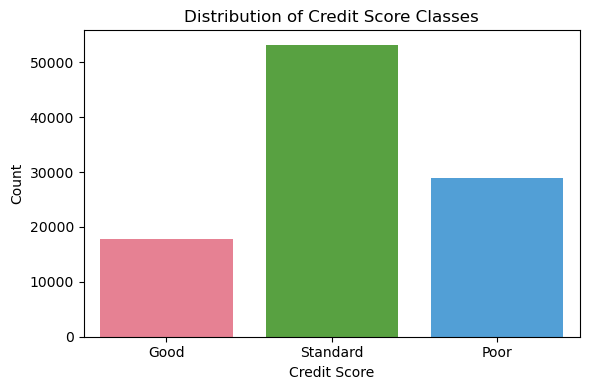

In [ ]:
# Visualize distributions of key features

#1 Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Credit_Score", palette="husl")
plt.title("Distribution of Credit Score Classes")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

0    23.0
1    23.0
3    23.0
4    23.0
5    23.0
Name: Age, dtype: float64
count    92369.000000
mean        33.316860
std         10.777813
min         14.000000
25%         24.000000
50%         33.000000
75%         42.000000
max         99.000000
Name: Age, dtype: float64


/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_70612/2986977090.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Credit_Score", y="Age", palette="husl")


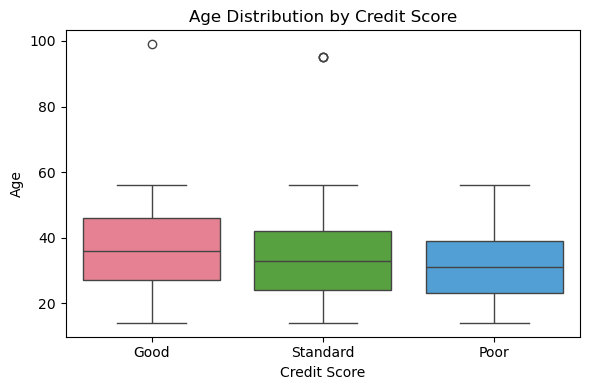

In [19]:
# 2 Age distribution by Credit Score

print(df['Age'].head())

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df = df[(df["Age"] > 0) & (df["Age"] < 100)]
print(df["Age"].describe())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Credit_Score", y="Age", palette="husl")
plt.title("Age Distribution by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Age")
plt.tight_layout()
plt.show()





/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_70612/2948162051.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


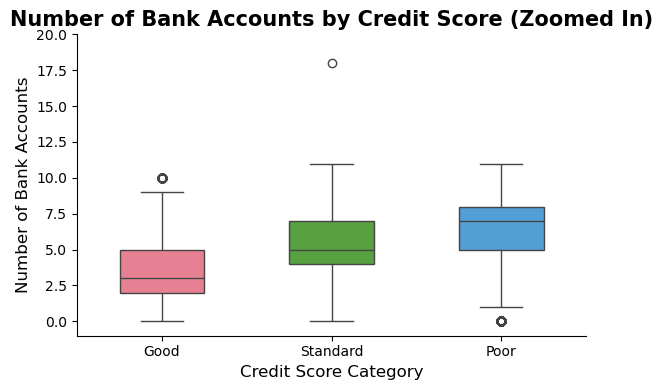

In [30]:
# 3 Bank account number distribution by Credit Score
df_cleaned = df[df["Num_Bank_Accounts"] >= 0]
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_cleaned,
    x="Credit_Score",
    y="Num_Bank_Accounts",
    order=["Good","Standard","Poor"],
    palette="husl",
    width=0.5
)

plt.title("Number of Bank Accounts by Credit Score (Zoomed In)", fontsize=15, weight='bold')
plt.xlabel("Credit Score Category", fontsize=12)
plt.ylabel("Number of Bank Accounts", fontsize=12)

plt.ylim(-1, 20)

sns.despine()
plt.tight_layout()
plt.show()



count    98991.000000
mean      1426.503700
std       1155.045753
min          0.230000
25%        566.080000
50%       1166.370000
75%       1948.200000
max       4998.070000
Name: Outstanding_Debt, dtype: float64


/var/folders/hs/fgtpkc7n7gg59wjjycgjmqv80000gn/T/ipykernel_71732/2406587792.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


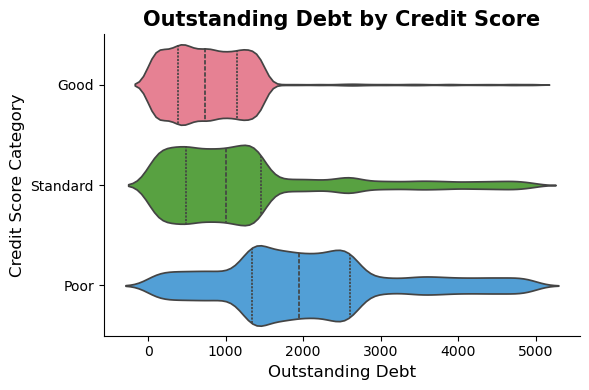

In [11]:
# 4 Outstanding Debt distribution by Credit Score
import numpy as np
df["Outstanding_Debt"] = (
    df["Outstanding_Debt"]
    .replace({",": ""}, regex=True) 
    .replace("NA", np.nan)              
)
df["Outstanding_Debt"] = pd.to_numeric(df["Outstanding_Debt"], errors="coerce")

print(df["Outstanding_Debt"].describe())
plt.figure(figsize=(6,4))
sns.violinplot(
    data=df,
    y="Credit_Score",
    x="Outstanding_Debt",
    order=["Good","Standard","Poor"],
    palette="husl",
    inner="quartile"
)
plt.title("Outstanding Debt by Credit Score", fontsize=15, weight='bold')
plt.xlabel("Outstanding Debt", fontsize=12)
plt.ylabel("Credit Score Category", fontsize=12)



sns.despine()
plt.tight_layout()
plt.show()


